# Overview: fine-tuned with a frozen head variants against the baseline (axis-100-3000)

Does any pretraining variant improve on the real-only baseline on the key reconstruction and head metrics, and which variant is best? Stage shown: **fine-tuned with a frozen head**, i.e. the pretrained model after 10 epochs on the real training data with the head frozen to the synthetic head (verified bitwise); encoder and decoder adapt.

## Introduction

The thesis tested in parts 2-6 is that synthetic pretraining improves on the model trained on real data only.
Every table therefore contains the **real-only baseline** of the same axis (10 real epochs from the same
initialization) and every comparison is a **paired difference to that baseline**.

The ten pretraining variants differ only in the synthetic data seen before real data (campaign methodology,
`pretraining_campaign_methodology.md`):

| Variant | Synthetic phases | Construction |
| --- | --- | --- |
| P0 single bins | 1 x 10 epochs | ten spectra per axis bin; annotated bins carry their labels, blank bins are known negatives |
| P1 permutations | 1 x 10 epochs | component-token bag (30 per class and per blank bin) packed into mixed spectra |
| P2 joint / staged | 1 x 10 / 2 x 10 epochs | P0 and P1 rows shuffled together / P0 first, then P1 |
| P3 joint / staged | as P2 | P2 + overlap quota (30 extra tokens per class that shares a bin with another class in a training pixel) |
| P4 joint / staged | as P2 | P2 + rare quota (30 extra tokens per class of the least-annotated quarter) |
| P5 joint / staged | as P2 | P2 + both quotas |

Every variant yields three models along one lineage (stages): `pretrained`, `frozen_head` and `unfrozen_head`.
The staged schedules train twice as many synthetic epochs as the joint ones, so schedule and budget are
confounded (methodology, "Pretraining ablation").

### Assumptions

* **Pairing.** Repetition $r$ uses one initialization seed for the baseline and for every variant and stage
  (verified for all 310 models in the campaign-plan verification). The difference between a variant and the
  baseline of the same repetition removes the initialization effect; the five repetitions are the independent
  units. Pixels are not independent units and never enter a test as such.
* **Data.** Every model is evaluated on identical pixels: the same `train`, `test`, `test_extended` and
  `heldout_image` populations as in part 1, decoded once in the shared cache.
* **Objectives.** Synthetic phases: Masserstein (1.0) + BCE (0.2) on complete synthetic targets. Real phases
  (baseline and both fine-tuning stages): Masserstein (1.0) + VPU (0.2) + contractive (2e-3) + InfoNCE (1e-3,
  multilabel-Jaccard negatives, added by mistake and kept because every model used it).
* **Threshold metrics.** Precision, recall and F1 use $\hat Y \ge 0.5$, as in part 1. A head whose
  probabilities never reach 0.5 on real data has F1 = 0 although its ranking may still carry information;
  average precision is threshold free and is the primary head metric.
* **Uncertainty.** With five repetitions the Student-t interval has 4 degrees of freedom
  ($t_{0.975,4} = 2.78$); an interval that excludes zero is a strong statement, one that includes zero is not
  evidence of no effect.

### Notation

* $b_r$, $v_r$: value of a metric for the baseline and for a variant (at one stage) in repetition $r$.
* $s_m \in \{-1, +1\}$: direction of metric $m$; $-1$ for lower-is-better metrics (Masserstein $W_1$,
  spectral angle, MSE, Hamming loss, window contribution and within-window $W_1$, absolute mass imbalance, ECE,
  Brier score, true-label rank, false-positive rate and lift, losses), $+1$ otherwise.
* **Improvement** $\Delta_r = s_m (v_r - b_r)$: positive is always better than the baseline.
  **Relative improvement** $\Delta_r / |b_r|$.
* Summary over repetitions: mean $\bar\Delta$, SD $s$, interval $\bar\Delta \pm t_{0.975, n-1}\, s / \sqrt{n}$,
  and the numbers of repetitions with $\Delta_r > 0$ (`+k`) and $\Delta_r < 0$ (`-m`).
* Evaluations: `test` (withheld pixels of training images), `test_combined` (test + rare-class extension, the
  main per-class estimate), `heldout_image` (three images never seen; pooled), `heldout_image_per_image` (mean of
  the per-image values; pooled held-out values understate the ranking because annotations are incomplete across
  images, part 1_08).
* $W_1$: exact one-dimensional Wasserstein-1 distance between TIC-normalized input and reconstruction (m/z
  units); $u$: canonical latent code (LayerNorm affine removed).

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "stage_overview"
AXIS = "axis-100-3000"
STAGE = "frozen_head"

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS, STAGE)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS, STAGE)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| stage:", STAGE, "| models:", metadata["models"] if isinstance(metadata["models"], int) else len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

BASELINE = "baseline"
VARIANTS = list(settings["variants"])
VARIANT_LABELS = {BASELINE: "real-only baseline", **{name: value["label"] for name, value in settings["variants"].items()}}
## The baseline keeps its catalog colour (the dark theme baseline colour is reserved for reference lines)
BASELINE_COLOR = next(value["visualization"]["color"] for value in settings["models"].values()
                      if value.get("select", {}).get("role") == settings["baseline_role"])
VARIANT_COLORS = {BASELINE: BASELINE_COLOR, **{name: value["color"] for name, value in settings["variants"].items()}}
STAGES = list(settings["stages"])
STAGE_LABELS = {"real_only": "real-only baseline", **{name: value["label"] for name, value in settings["stages"].items()}}
KEY_METRICS = settings["comparison"]["key_metrics"]
AXES = list(settings["axes"])
AXIS_LABELS = {name: value["label"] for name, value in settings["axes"].items()}
SHORT = {"masserstein": "W1", "spectral_angle": "spectral angle", "average_precision": "macro AP",
         "micro_average_precision": "micro AP", "f1": "macro F1 at 0.5"}
EVALUATION_NAMES = {**figures.DISPLAY_NAMES, "heldout_image_per_image": "held-out, per image"}


def key_panels(reconstruction=("test", "heldout_image"), prediction=("test_combined", "heldout_image_per_image")):
    """Forest-plot panels of the key metrics: (title, row selector)."""
    panels = []
    for spec in KEY_METRICS:
        for evaluation in (reconstruction if spec["family"] == "reconstruction" else prediction):
            selector = {"family": spec["family"], "metric": spec["metric"], "evaluation": evaluation,
                        "ranking": spec.get("ranking", "none")}
            panels.append((f"{SHORT.get(spec['metric'], spec['metric'])}, {EVALUATION_NAMES.get(evaluation, evaluation)}", selector))
    return panels


def interval(frame, digits=3):
    """'mean [ci_low, ci_high] (+k/-m)' strings of a summary table."""
    form = "{:." + str(digits) + "g}"
    return (frame["mean"].map(form.format) + " [" + frame.ci_low.map(form.format) + ", "
            + frame.ci_high.map(form.format) + "] (+" + frame.positive.astype(int).astype(str) + "/-"
            + frame.negative.astype(int).astype(str) + ")")

from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_comparison import summarize

ORDER = [BASELINE, *VARIANTS]
EVALUATIONS = ['test', 'test_combined', 'heldout_image', 'heldout_image_per_image']

metrics = table('model_metrics')
paired = table('improvements')
improvement_summary = table('improvement_summary')
values = table('value_summary')
print('Best variant on the test pixels:', metadata['best_variant'])

Analysis: stage_overview | axis: axis-100-3000 | stage: frozen_head | models: 55
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'synthetic_reference': '6ba5bc1e0839ba0e', 'inference': '0243c1efb93b9c4c'}
Best variant on the test pixels: P1_permutation


## Producing the tables this notebook reads

### Methodology

#### Implementation

`stage_overview` reads, per model, the population means of the per-pixel reconstruction metrics and the
whole-axis head ranking table (scope `train_supported`, group `all`) written by the `inference` level,
plus the per-image held-out head metrics. It pairs every variant model with the baseline of the same
repetition, summarizes the improvements over repetitions and ranks the variants.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis stage_overview > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Absolute results of every variant and of the real-only baseline

### Methodology

#### Theoretical

The paired improvements below answer *whether* a variant differs from the baseline; this section shows *what
every model reaches*: the absolute value of every key metric for the real-only baseline and for every variant,
so that a difference can be read against the level at which it happens.

#### Implementation

`model_metrics` holds one value per model, metric and evaluation population (repetitions of a variant = its five models).

#### Figure descriptions

        First figure: one panel per key metric and evaluation; x = baseline and variants, violin and points = the five
        repetitions, bar = mean. Tables: the reconstruction metrics on test and held-out pixels, then the complete
        prediction metric set (annotation retrieval, training-supported classes) per evaluation population.

Colours: in the figures the baseline is grey (its mean is the dashed line) and every other group is green when its
mean is better than the baseline mean and red when it is worse. In the tables every cell is mean +/- SD over the
repetitions; green / red cells are better / worse than the baseline cell of the same column (stronger colour = larger
difference within the column), the black frame marks the three best rows of the column and the grey bold row is the
real-only baseline.

In [3]:
LOWER_IS_BETTER = {'masserstein', 'spectral_angle', 'mse', 'hamming_loss', 'expected_calibration_error', 'brier_score',
                   'within', 'contribution', 'absolute_mass_imbalance', 'bic'}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1', 'micro_prevalence',
                'hamming_loss']
ABS_ORDER = [BASELINE, *VARIANTS]
LABELS_ABS = {**VARIANT_LABELS, **{name: VARIANT_LABELS.get(name, name) for name in ABS_ORDER}}


def better(metric):
    """Direction of a metric: 'lower' or 'higher' is better."""
    return 'lower' if metric in LOWER_IS_BETTER else 'higher'

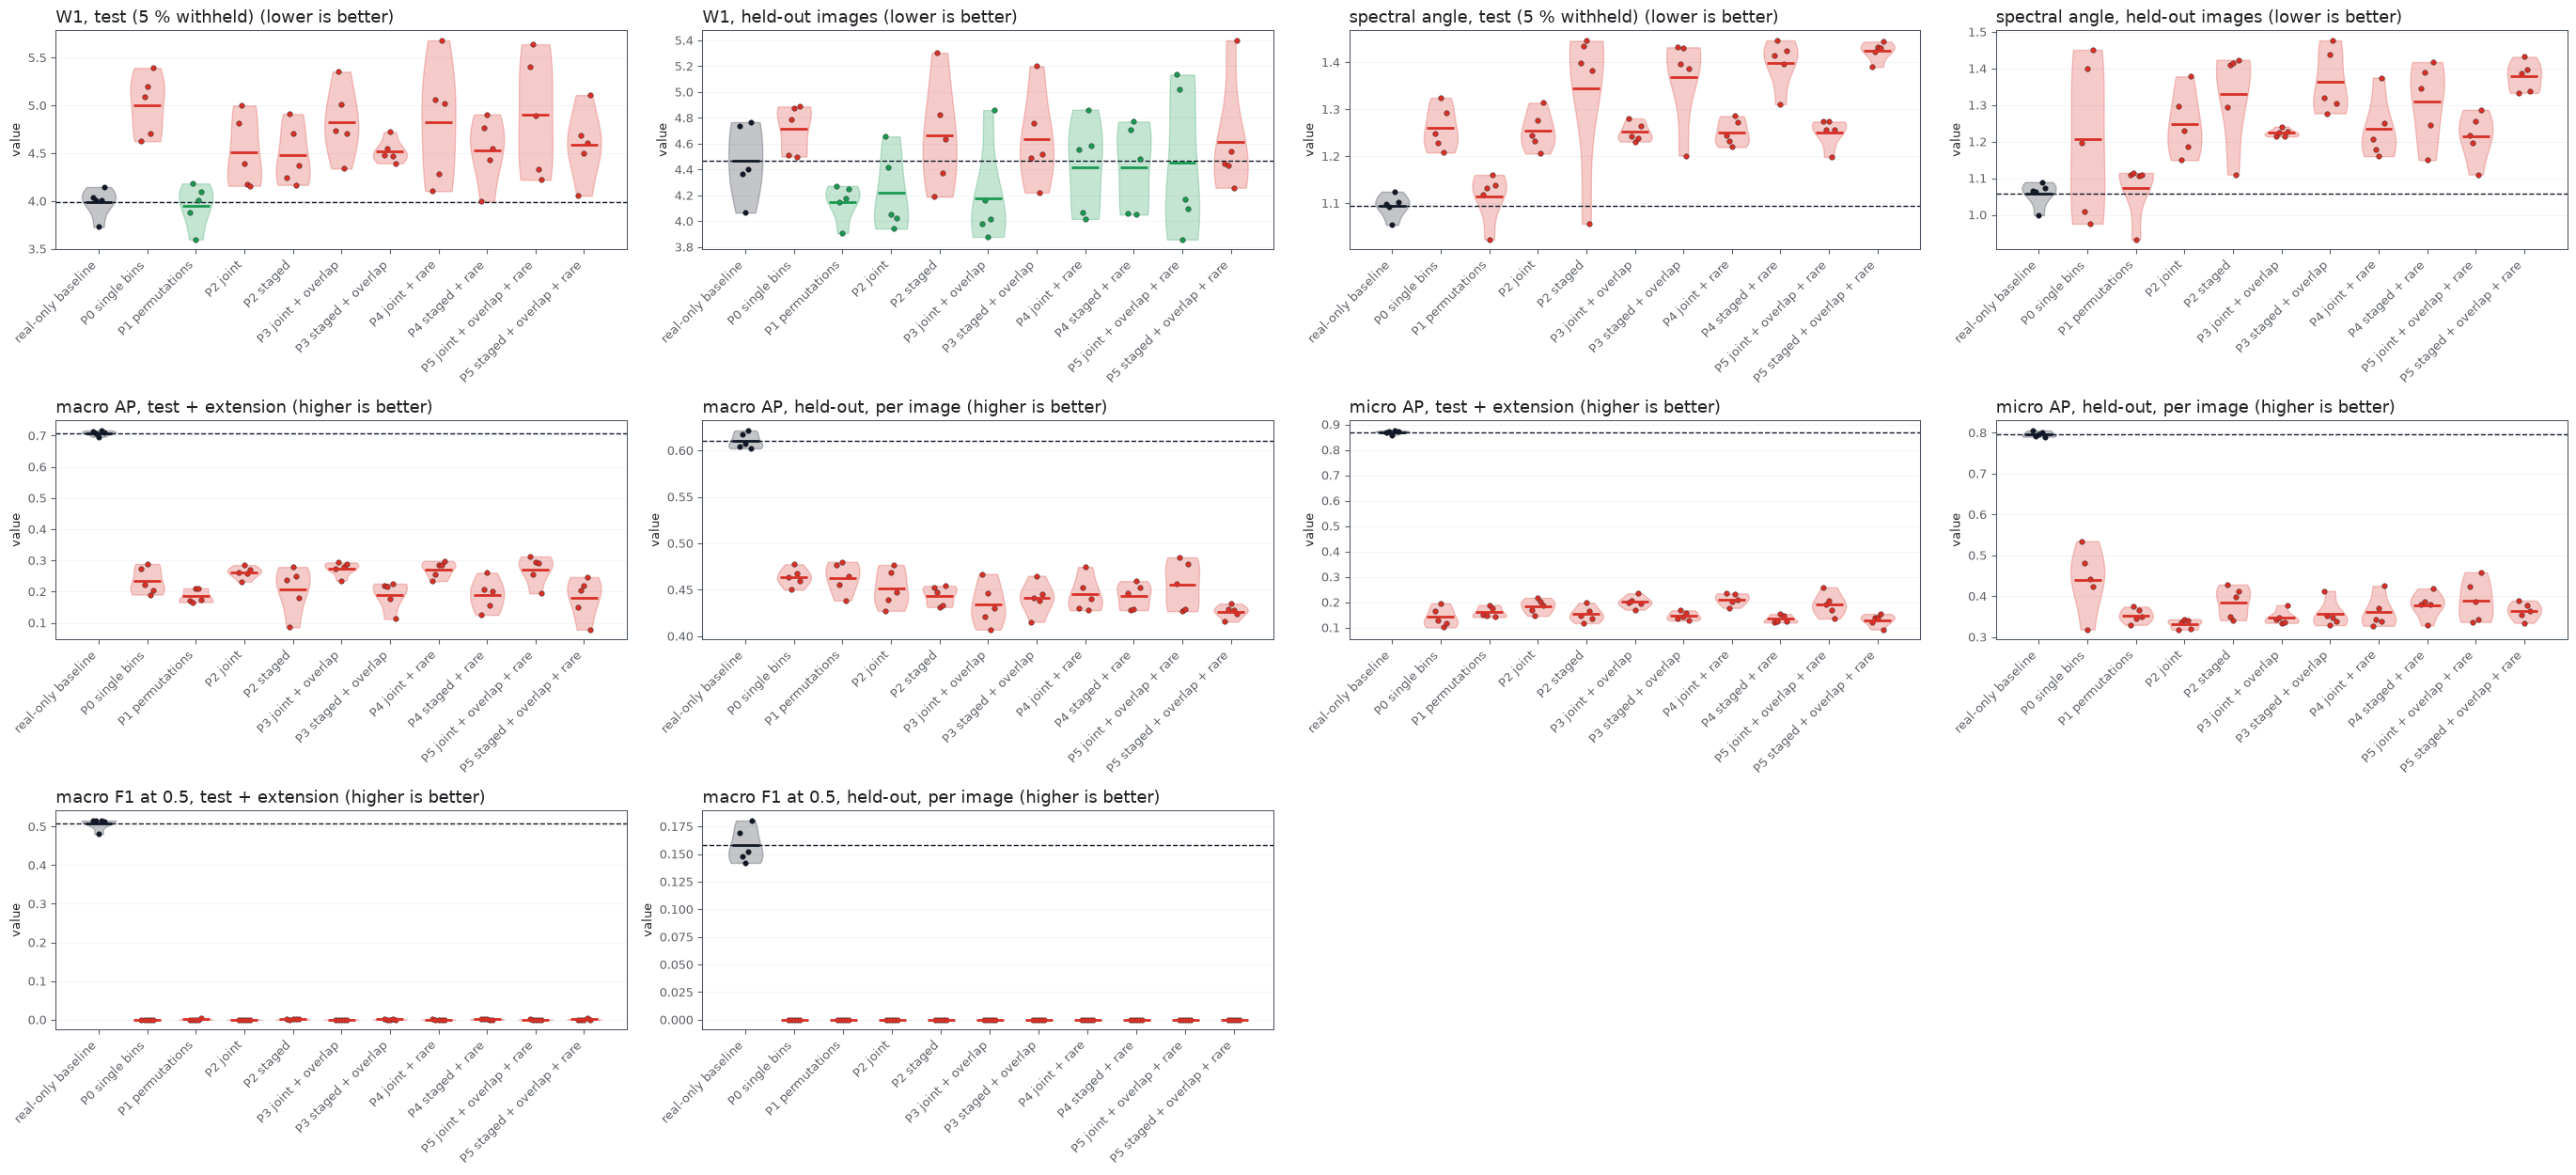

In [4]:
metrics_abs = table('model_metrics')

panels = []
for spec in KEY_METRICS:
    evaluations = ['test', 'heldout_image'] if spec['family'] == 'reconstruction' else ['test_combined', 'heldout_image_per_image']
    for evaluation in evaluations:
        panels.append((f"{SHORT[spec['metric']]}, {EVALUATION_NAMES.get(evaluation, evaluation)}",
                       {'family': spec['family'], 'metric': spec['metric'], 'evaluation': evaluation,
                        'ranking': spec.get('ranking', 'none')}, better(spec['metric'])))
figures.metric_panels(metrics_abs, panels=panels, group='variant', order=ABS_ORDER, labels=LABELS_ABS, baseline=BASELINE, columns=4, theme=theme);

In [5]:
recon = metrics_abs[(metrics_abs.family == 'reconstruction') & metrics_abs.evaluation.isin(['test', 'heldout_image'])]
recon = recon.assign(column=recon.metric + ' | ' + recon.evaluation)
columns = [f'{metric} | {evaluation}' for evaluation in ('test', 'heldout_image') for metric in ('masserstein', 'spectral_angle', 'cosine_similarity', 'mse')]
display(figures.comparison_table(recon, index='variant', columns='column', baseline=BASELINE, order=ABS_ORDER, column_order=columns,
                                 direction={column: better(column.split(' | ')[0]) for column in columns}))
prediction_abs = metrics_abs[(metrics_abs.family == 'prediction') & (metrics_abs.ranking == 'annotation_retrieval')]
for evaluation in ('test_combined', 'heldout_image', 'heldout_image_per_image'):
    rows = prediction_abs[prediction_abs.evaluation == evaluation]
    if rows.empty:
        continue
    print(EVALUATION_NAMES.get(evaluation, evaluation))
    display(figures.comparison_table(rows, index='variant', columns='metric', baseline=BASELINE, order=ABS_ORDER,
                                     column_order=METRIC_ORDER, direction={metric: better(metric) for metric in rows.metric.unique()}))

column,masserstein | test,spectral_angle | test,cosine_similarity | test,mse | test,masserstein | heldout_image,spectral_angle | heldout_image,cosine_similarity | heldout_image,mse | heldout_image
variant,,,,,,,,
baseline,3.988 +/- 0.155,1.094 +/- 0.026,0.457 +/- 0.023,0.000 +/- 0.000,4.467 +/- 0.290,1.058 +/- 0.035,0.490 +/- 0.030,0.000 +/- 0.000
P0_single,5.004 +/- 0.327,1.260 +/- 0.047,0.298 +/- 0.045,0.000 +/- 0.000,4.713 +/- 0.192,1.206 +/- 0.218,0.347 +/- 0.201,0.000 +/- 0.000
P1_permutation,3.954 +/- 0.228,1.114 +/- 0.053,0.439 +/- 0.047,0.000 +/- 0.000,4.150 +/- 0.145,1.074 +/- 0.079,0.475 +/- 0.068,0.000 +/- 0.000
P2_joint_base,4.508 +/- 0.382,1.255 +/- 0.042,0.308 +/- 0.040,0.000 +/- 0.000,4.218 +/- 0.305,1.248 +/- 0.091,0.315 +/- 0.087,0.000 +/- 0.000
P2_staged_base,4.481 +/- 0.316,1.344 +/- 0.163,0.215 +/- 0.139,0.000 +/- 0.000,4.664 +/- 0.432,1.331 +/- 0.134,0.234 +/- 0.126,0.000 +/- 0.000
P3_joint_overlap,4.829 +/- 0.378,1.252 +/- 0.020,0.312 +/- 0.019,0.000 +/- 0.000,4.180 +/- 0.393,1.224 +/- 0.011,0.339 +/- 0.010,0.000 +/- 0.000
P3_staged_overlap,4.524 +/- 0.124,1.369 +/- 0.096,0.191 +/- 0.078,0.000 +/- 0.000,4.638 +/- 0.367,1.363 +/- 0.088,0.204 +/- 0.086,0.000 +/- 0.000
P4_joint_rare,4.830 +/- 0.639,1.251 +/- 0.028,0.312 +/- 0.028,0.000 +/- 0.000,4.418 +/- 0.364,1.234 +/- 0.086,0.328 +/- 0.083,0.000 +/- 0.000
P4_staged_rare,4.532 +/- 0.351,1.398 +/- 0.052,0.170 +/- 0.050,0.000 +/- 0.000,4.415 +/- 0.345,1.310 +/- 0.111,0.256 +/- 0.106,0.000 +/- 0.000


test + extension


metric,average_precision,micro_average_precision,roc_auc,ap_above_prevalence,precision,recall,f1,micro_f1,hamming_loss
variant,,,,,,,,,
baseline,0.708 +/- 0.008,0.870 +/- 0.007,0.987 +/- 0.001,0.651 +/- 0.008,0.588 +/- 0.010,0.529 +/- 0.017,0.508 +/- 0.015,0.826 +/- 0.005,0.020 +/- 0.001
P0_single,0.236 +/- 0.043,0.141 +/- 0.039,0.727 +/- 0.039,0.178 +/- 0.043,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.057 +/- 0.000
P1_permutation,0.186 +/- 0.022,0.161 +/- 0.021,0.711 +/- 0.043,0.129 +/- 0.022,0.006 +/- 0.006,0.001 +/- 0.001,0.001 +/- 0.002,0.006 +/- 0.010,0.058 +/- 0.000
P2_joint_base,0.262 +/- 0.020,0.184 +/- 0.028,0.739 +/- 0.034,0.204 +/- 0.020,0.001 +/- 0.001,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.057 +/- 0.000
P2_staged_base,0.206 +/- 0.076,0.153 +/- 0.030,0.661 +/- 0.103,0.148 +/- 0.076,0.005 +/- 0.003,0.001 +/- 0.001,0.001 +/- 0.000,0.004 +/- 0.002,0.058 +/- 0.001
P3_joint_overlap,0.274 +/- 0.023,0.201 +/- 0.024,0.752 +/- 0.013,0.216 +/- 0.023,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.057 +/- 0.000
P3_staged_overlap,0.190 +/- 0.047,0.146 +/- 0.017,0.688 +/- 0.045,0.133 +/- 0.047,0.004 +/- 0.002,0.001 +/- 0.000,0.001 +/- 0.001,0.003 +/- 0.002,0.058 +/- 0.000
P4_joint_rare,0.272 +/- 0.026,0.212 +/- 0.024,0.752 +/- 0.011,0.214 +/- 0.026,0.001 +/- 0.001,0.000 +/- 0.000,0.000 +/- 0.000,0.001 +/- 0.001,0.057 +/- 0.000
P4_staged_rare,0.190 +/- 0.052,0.134 +/- 0.015,0.635 +/- 0.050,0.133 +/- 0.052,0.003 +/- 0.003,0.002 +/- 0.001,0.001 +/- 0.001,0.007 +/- 0.007,0.058 +/- 0.000


held-out images


metric,average_precision,micro_average_precision,roc_auc,ap_above_prevalence,precision,recall,f1,micro_f1,hamming_loss
variant,,,,,,,,,
baseline,0.376 +/- 0.016,0.581 +/- 0.019,0.726 +/- 0.013,0.154 +/- 0.016,0.360 +/- 0.044,0.119 +/- 0.012,0.128 +/- 0.016,0.381 +/- 0.030,0.191 +/- 0.005
P0_single,0.257 +/- 0.008,0.232 +/- 0.038,0.482 +/- 0.032,0.035 +/- 0.008,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.222 +/- 0.000
P1_permutation,0.261 +/- 0.010,0.197 +/- 0.012,0.542 +/- 0.038,0.039 +/- 0.010,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.222 +/- 0.000
P2_joint_base,0.248 +/- 0.014,0.182 +/- 0.009,0.512 +/- 0.019,0.026 +/- 0.014,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.222 +/- 0.000
P2_staged_base,0.247 +/- 0.008,0.206 +/- 0.011,0.499 +/- 0.028,0.025 +/- 0.008,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.222 +/- 0.000
P3_joint_overlap,0.241 +/- 0.012,0.186 +/- 0.014,0.480 +/- 0.028,0.018 +/- 0.012,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.222 +/- 0.000
P3_staged_overlap,0.245 +/- 0.015,0.195 +/- 0.017,0.506 +/- 0.056,0.023 +/- 0.015,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.222 +/- 0.000
P4_joint_rare,0.243 +/- 0.011,0.201 +/- 0.027,0.480 +/- 0.034,0.021 +/- 0.011,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.222 +/- 0.000
P4_staged_rare,0.244 +/- 0.013,0.202 +/- 0.018,0.491 +/- 0.020,0.022 +/- 0.013,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.222 +/- 0.000


held-out, per image


metric,average_precision,micro_average_precision,roc_auc,ap_above_prevalence,precision,recall,f1,micro_f1,hamming_loss
variant,,,,,,,,,
baseline,0.610 +/- 0.008,0.797 +/- 0.007,0.770 +/- 0.007,0.201 +/- 0.008,0.470 +/- 0.048,0.140 +/- 0.010,0.158 +/- 0.016,0.410 +/- 0.034,0.314 +/- 0.011
P0_single,0.464 +/- 0.010,0.440 +/- 0.080,0.491 +/- 0.012,0.054 +/- 0.010,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.410 +/- 0.000
P1_permutation,0.463 +/- 0.017,0.353 +/- 0.017,0.519 +/- 0.021,0.053 +/- 0.017,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.410 +/- 0.000
P2_joint_base,0.452 +/- 0.021,0.331 +/- 0.012,0.503 +/- 0.015,0.042 +/- 0.021,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.410 +/- 0.000
P2_staged_base,0.444 +/- 0.011,0.385 +/- 0.039,0.507 +/- 0.027,0.034 +/- 0.011,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.410 +/- 0.000
P3_joint_overlap,0.434 +/- 0.023,0.348 +/- 0.018,0.492 +/- 0.025,0.025 +/- 0.023,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.410 +/- 0.000
P3_staged_overlap,0.441 +/- 0.018,0.356 +/- 0.033,0.507 +/- 0.032,0.031 +/- 0.018,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.410 +/- 0.000
P4_joint_rare,0.445 +/- 0.019,0.361 +/- 0.040,0.494 +/- 0.022,0.035 +/- 0.019,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.410 +/- 0.000
P4_staged_rare,0.443 +/- 0.014,0.379 +/- 0.032,0.515 +/- 0.021,0.033 +/- 0.014,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.410 +/- 0.000


### Remarks

- W1, test: baseline 3.988; others 3.954-5.004; 1 of 10 better than the baseline; best P1 permutations (3.954), worst P0 single bins (5.004).
- W1, heldout_image: baseline 4.467; others 4.15-4.713; 6 of 10 better than the baseline; best P1 permutations (4.15), worst P0 single bins (4.713).
- spectral angle, test: baseline 1.094; others 1.114-1.424; 0 of 10 better than the baseline; best P1 permutations (1.114), worst P5 staged + overlap + rare (1.424).
- spectral angle, heldout_image: baseline 1.058; others 1.074-1.378; 0 of 10 better than the baseline; best P1 permutations (1.074), worst P5 staged + overlap + rare (1.378).
- macro AP, test_combined: baseline 0.7084; others 0.1793-0.2738; 0 of 10 better than the baseline; best P3 joint + overlap (0.2738), worst P5 staged + overlap + rare (0.1793).
- macro AP, heldout_image_per_image: baseline 0.6105; others 0.4263-0.4636; 0 of 10 better than the baseline; best P0 single bins (0.4636), worst P5 staged + overlap + rare (0.4263).
- micro AP, test_combined: baseline 0.8696; others 0.1294-0.2116; 0 of 10 better than the baseline; best P4 joint + rare (0.2116), worst P5 staged + overlap + rare (0.1294).
- micro AP, heldout_image_per_image: baseline 0.7966; others 0.3314-0.4396; 0 of 10 better than the baseline; best P0 single bins (0.4396), worst P2 joint (0.3314).
- macro F1 at 0.5, test_combined: baseline 0.508; others 0-0.001339; 0 of 10 better than the baseline; best P4 staged + rare (0.001339), worst P0 single bins (0).
- macro F1 at 0.5, heldout_image_per_image: baseline 0.1583; others 0-0; 0 of 10 better than the baseline; best P0 single bins (0), worst P0 single bins (0).

### Notes

## Key metrics of every variant and of the baseline

### Methodology

#### Theoretical

The five key metrics are those of the part 1 representative choice: Masserstein $W_1$ and spectral angle of
the reconstruction, macro AP, micro AP and macro F1 at 0.5 of the head (annotation retrieval, classes
observed in training). Reconstruction is shown on the withheld test pixels and on the held-out images, the
head on test + extension and per held-out image.

#### Implementation

`model_metrics` (one row per model, metric and evaluation); the table gives mean +/- SD over the five
repetitions from `value_summary`.

#### Figure descriptions

One panel per key metric; x = variant (baseline first), colour = evaluation, one point per repetition, bar =
mean. $W_1$ is drawn on a log scale because untrained-on-real models can be two orders of magnitude worse.

column,W1 | heldout_image,W1 | test,macro AP | heldout_image,macro AP | heldout_image_per_image,macro AP | test,macro AP | test_combined,macro F1 at 0.5 | heldout_image,macro F1 at 0.5 | heldout_image_per_image,macro F1 at 0.5 | test,macro F1 at 0.5 | test_combined,micro AP | heldout_image,micro AP | heldout_image_per_image,micro AP | test,micro AP | test_combined,spectral angle | heldout_image,spectral angle | test
variant,,,,,,,,,,,,,,,,
baseline,4.467 +/- 0.29,3.988 +/- 0.16,0.3761 +/- 0.016,0.6105 +/- 0.0084,0.6973 +/- 0.0089,0.7084 +/- 0.0079,0.1276 +/- 0.016,0.1583 +/- 0.016,0.5047 +/- 0.015,0.508 +/- 0.015,0.5809 +/- 0.019,0.7966 +/- 0.0068,0.8774 +/- 0.0074,0.8696 +/- 0.0066,1.058 +/- 0.035,1.094 +/- 0.026
P0_single,4.713 +/- 0.19,5.004 +/- 0.33,0.257 +/- 0.0075,0.4636 +/- 0.01,0.2246 +/- 0.043,0.2355 +/- 0.043,0 +/- 0,0 +/- 0,0 +/- 0,0 +/- 0,0.2316 +/- 0.038,0.4396 +/- 0.08,0.1216 +/- 0.032,0.1415 +/- 0.039,1.206 +/- 0.22,1.26 +/- 0.047
P1_permutation,4.15 +/- 0.15,3.954 +/- 0.23,0.261 +/- 0.01,0.4629 +/- 0.017,0.1802 +/- 0.021,0.1863 +/- 0.022,0 +/- 0,0 +/- 0,0.0009344 +/- 0.0016,0.001129 +/- 0.0017,0.1967 +/- 0.012,0.3527 +/- 0.017,0.1753 +/- 0.024,0.1611 +/- 0.021,1.074 +/- 0.079,1.114 +/- 0.053
P2_joint_base,4.218 +/- 0.3,4.508 +/- 0.38,0.2483 +/- 0.014,0.4519 +/- 0.021,0.2347 +/- 0.025,0.2617 +/- 0.02,0 +/- 0,0 +/- 0,0.0001164 +/- 9.8e-05,0.0001232 +/- 0.00011,0.1816 +/- 0.0085,0.3314 +/- 0.012,0.1993 +/- 0.036,0.1843 +/- 0.028,1.248 +/- 0.091,1.255 +/- 0.042
P2_staged_base,4.664 +/- 0.43,4.481 +/- 0.32,0.2468 +/- 0.0085,0.4437 +/- 0.011,0.1768 +/- 0.079,0.2058 +/- 0.076,0 +/- 0,0 +/- 0,0.0008888 +/- 0.00044,0.0009431 +/- 0.00045,0.2063 +/- 0.011,0.3853 +/- 0.039,0.1579 +/- 0.031,0.153 +/- 0.03,1.331 +/- 0.13,1.344 +/- 0.16
P3_joint_overlap,4.18 +/- 0.39,4.829 +/- 0.38,0.2407 +/- 0.012,0.4343 +/- 0.023,0.2603 +/- 0.026,0.2738 +/- 0.023,0 +/- 0,0 +/- 0,6.916e-05 +/- 0.00015,6.88e-05 +/- 0.00015,0.1862 +/- 0.014,0.3477 +/- 0.018,0.2226 +/- 0.032,0.2011 +/- 0.024,1.224 +/- 0.011,1.252 +/- 0.02
P3_staged_overlap,4.638 +/- 0.37,4.524 +/- 0.12,0.2454 +/- 0.015,0.441 +/- 0.018,0.1786 +/- 0.024,0.1901 +/- 0.047,0 +/- 0,0 +/- 0,0.0007562 +/- 0.00068,0.0008042 +/- 0.00062,0.1945 +/- 0.017,0.3557 +/- 0.033,0.1594 +/- 0.021,0.1464 +/- 0.017,1.363 +/- 0.088,1.369 +/- 0.096
P4_joint_rare,4.418 +/- 0.36,4.83 +/- 0.64,0.2428 +/- 0.011,0.445 +/- 0.019,0.2635 +/- 0.025,0.2718 +/- 0.026,0 +/- 0,0 +/- 0,0.0002239 +/- 0.00044,0.0002227 +/- 0.00044,0.2006 +/- 0.027,0.3607 +/- 0.04,0.2484 +/- 0.042,0.2116 +/- 0.024,1.234 +/- 0.086,1.251 +/- 0.028
P4_staged_rare,4.415 +/- 0.34,4.532 +/- 0.35,0.2444 +/- 0.013,0.4429 +/- 0.014,0.1603 +/- 0.05,0.1901 +/- 0.052,0 +/- 0,0 +/- 0,0.001358 +/- 0.0013,0.001339 +/- 0.0013,0.2024 +/- 0.018,0.3785 +/- 0.032,0.1395 +/- 0.023,0.134 +/- 0.015,1.31 +/- 0.11,1.398 +/- 0.052


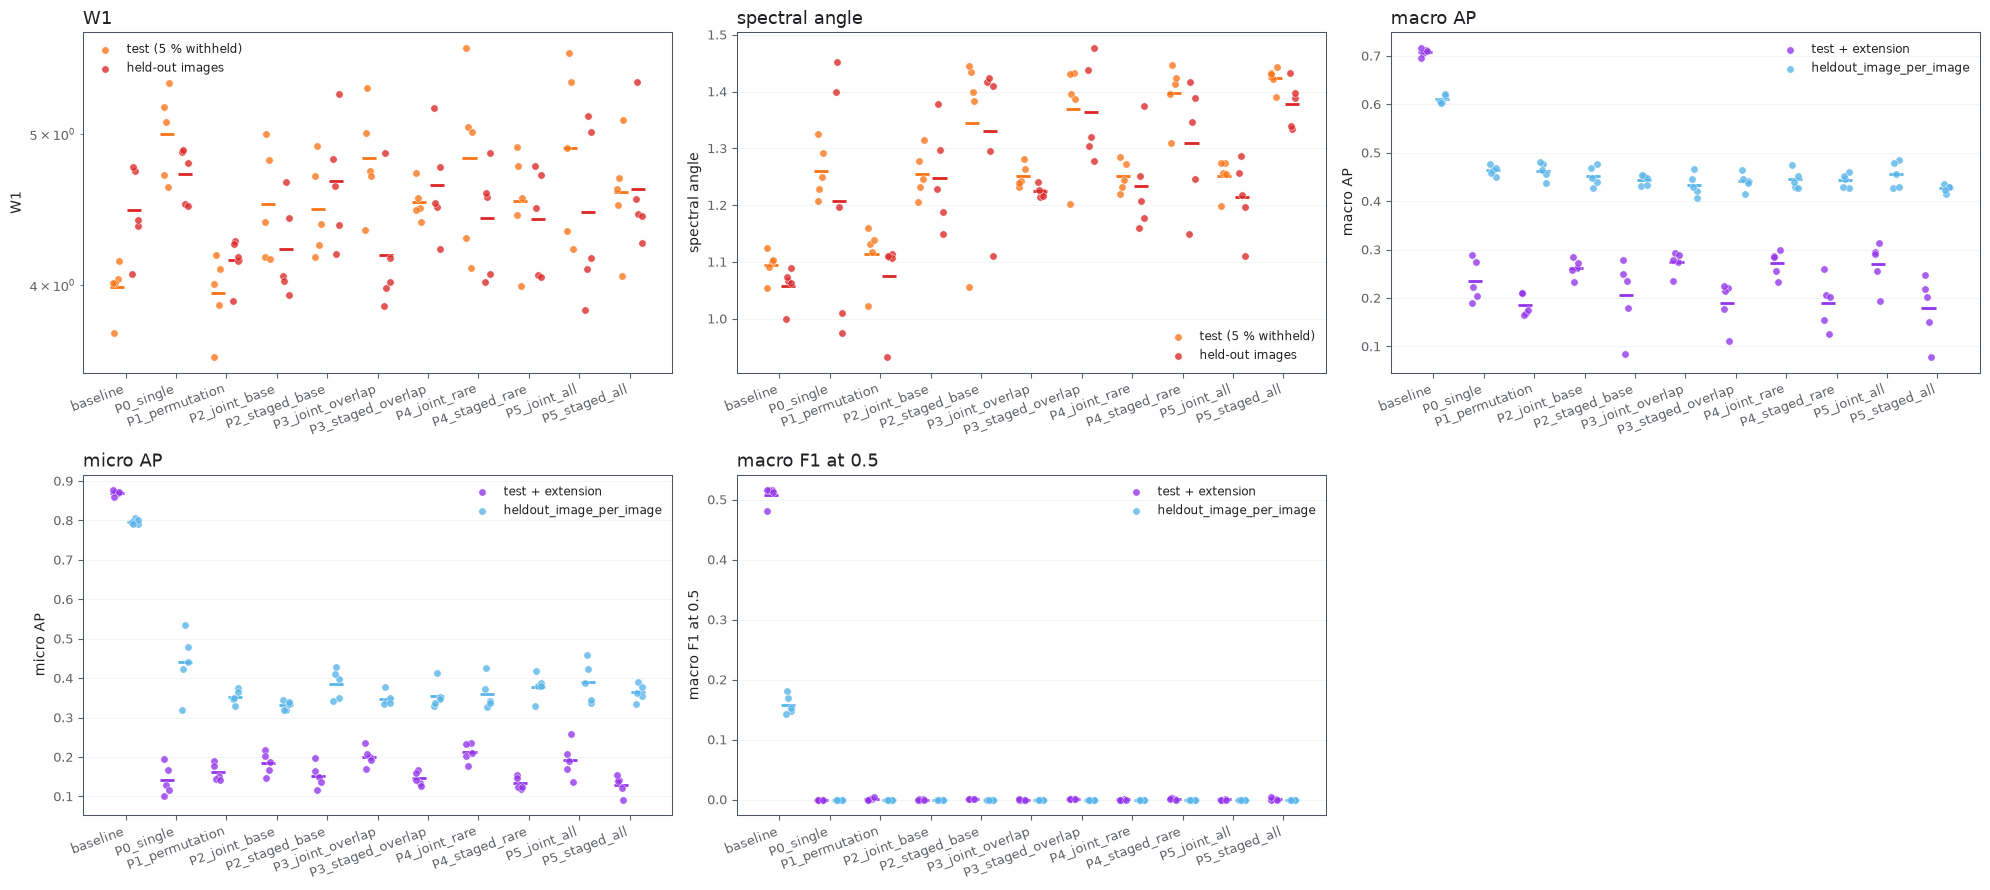

In [6]:
figure, axes = plt.subplots(2, 3, figsize=(20, 9), dpi=theme.figure_dpi)
for ax, spec in zip(axes.flat, KEY_METRICS):
    evaluations = ['test', 'heldout_image'] if spec['family'] == 'reconstruction' else ['test_combined', 'heldout_image_per_image']
    rows = metrics[(metrics.family == spec['family']) & (metrics.metric == spec['metric'])
                   & (metrics.ranking == spec.get('ranking', 'none')) & metrics.evaluation.isin(evaluations)]
    figures.repetition_points(rows, value='value', group='variant', hue='evaluation', order=ORDER, hue_order=evaluations,
                              colors={name: POPULATION_COLORS.get(name, theme.model_palette[5]) for name in evaluations},
                              ylabel=SHORT[spec['metric']], title=SHORT[spec['metric']], ax=ax, theme=theme)
    if spec['metric'] == 'masserstein':
        ax.set_yscale('log')
axes.flat[-1].set_visible(False)
figure.tight_layout()
key = pd.concat([values[(values.family == spec['family']) & (values.metric == spec['metric'])
                        & (values.ranking == spec.get('ranking', 'none'))] for spec in KEY_METRICS])
key = key[key.evaluation.isin(EVALUATIONS)]
cells = key.assign(cell=key['mean'].map('{:.4g}'.format) + ' +/- ' + key.sd.map('{:.2g}'.format),
                   column=key.metric.map(SHORT) + ' | ' + key.evaluation)
display(cells.pivot_table(index='variant', columns='column', values='cell', aggfunc='first').reindex(ORDER))

### Remarks

- Baseline: W1 test 3.988 +/- 0.16; W1 held-out 4.467 +/- 0.29; spectral angle test 1.094 +/- 0.026; spectral angle held-out 1.058 +/- 0.035; macro AP held-out 0.3761 +/- 0.016; macro AP test+ext 0.7084 +/- 0.0079; macro AP held-out per image 0.6105 +/- 0.0084; micro AP held-out 0.5809 +/- 0.019; micro AP test+ext 0.8696 +/- 0.0066; micro AP held-out per image 0.7966 +/- 0.0068; macro F1@0.5 held-out 0.1276 +/- 0.016; macro F1@0.5 test+ext 0.508 +/- 0.015; macro F1@0.5 held-out per image 0.1583 +/- 0.016.
- W1, test: variants 3.954 to 5.004 (baseline 3.988).
- W1, held-out: variants 4.15 to 4.713 (baseline 4.467).
- spectral angle, test: variants 1.114 to 1.424 (baseline 1.094).
- spectral angle, held-out: variants 1.074 to 1.378 (baseline 1.058).
- macro AP, held-out: variants 0.234 to 0.261 (baseline 0.3761).
- macro AP, test+ext: variants 0.1793 to 0.2738 (baseline 0.7084).
- macro AP, held-out per image: variants 0.4263 to 0.4636 (baseline 0.6105).
- micro AP, held-out: variants 0.1816 to 0.2316 (baseline 0.5809).
- micro AP, test+ext: variants 0.1294 to 0.2116 (baseline 0.8696).
- micro AP, held-out per image: variants 0.3314 to 0.4396 (baseline 0.7966).
- macro F1@0.5, held-out: variants 0 to 0 (baseline 0.1276).
- macro F1@0.5, test+ext: variants 0 to 0.001339 (baseline 0.508).
- macro F1@0.5, held-out per image: variants 0 to 0 (baseline 0.1583).

### Notes

## Paired improvement over the baseline

### Methodology

#### Theoretical

The improvement $\Delta_r = s_m (v_r - b_r)$ of every repetition and its summary over repetitions answer
the main question directly: an interval entirely above zero means the variant is better than the baseline
in this stage, entirely below zero means worse.

#### Implementation

`improvements` (per repetition) and `improvement_summary` (mean, SD, 95 % t interval, sign counts).

#### Figure descriptions

Forest plot: one panel per key metric and evaluation; rows = variants; diamond = mean improvement, bar = 95 %
interval, small dots = the five repetitions; the dashed vertical line is the baseline. The table gives
`mean [interval] (+improving/-worsening repetitions)`.

column,W1 | heldout_image,W1 | test,macro AP | heldout_image,macro AP | heldout_image_per_image,macro AP | test,macro AP | test_combined,macro F1 at 0.5 | heldout_image,macro F1 at 0.5 | heldout_image_per_image,macro F1 at 0.5 | test,macro F1 at 0.5 | test_combined,micro AP | heldout_image,micro AP | heldout_image_per_image,micro AP | test,micro AP | test_combined,spectral angle | heldout_image,spectral angle | test
variant,,,,,,,,,,,,,,,,
P0_single,"-0.245 [-0.728, 0.238] (+1/-4)","-1.02 [-1.48, -0.555] (+0/-5)","-0.119 [-0.144, -0.0943] (+0/-5)","-0.147 [-0.164, -0.13] (+0/-5)","-0.473 [-0.532, -0.413] (+0/-5)","-0.473 [-0.534, -0.412] (+0/-5)","-0.128 [-0.147, -0.108] (+0/-5)","-0.158 [-0.178, -0.139] (+0/-5)","-0.505 [-0.523, -0.486] (+0/-5)","-0.508 [-0.527, -0.489] (+0/-5)","-0.349 [-0.387, -0.312] (+0/-5)","-0.357 [-0.453, -0.261] (+0/-5)","-0.756 [-0.804, -0.708] (+0/-5)","-0.728 [-0.784, -0.672] (+0/-5)","-0.148 [-0.443, 0.147] (+2/-3)","-0.166 [-0.253, -0.0794] (+0/-5)"
P1_permutation,"0.317 [0.118, 0.517] (+5/-0)","0.0338 [-0.127, 0.195] (+4/-1)","-0.115 [-0.136, -0.0944] (+0/-5)","-0.148 [-0.178, -0.117] (+0/-5)","-0.517 [-0.546, -0.488] (+0/-5)","-0.522 [-0.553, -0.491] (+0/-5)","-0.128 [-0.147, -0.108] (+0/-5)","-0.158 [-0.178, -0.139] (+0/-5)","-0.504 [-0.522, -0.485] (+0/-5)","-0.507 [-0.525, -0.488] (+0/-5)","-0.384 [-0.413, -0.355] (+0/-5)","-0.444 [-0.471, -0.417] (+0/-5)","-0.702 [-0.738, -0.666] (+0/-5)","-0.708 [-0.74, -0.677] (+0/-5)","-0.0161 [-0.0755, 0.0433] (+1/-4)","-0.0199 [-0.0568, 0.017] (+1/-4)"
P2_joint_base,"0.249 [-0.174, 0.673] (+4/-1)","-0.52 [-1.04, -0.00268] (+0/-5)","-0.128 [-0.153, -0.103] (+0/-5)","-0.159 [-0.181, -0.136] (+0/-5)","-0.463 [-0.496, -0.429] (+0/-5)","-0.447 [-0.476, -0.417] (+0/-5)","-0.128 [-0.147, -0.108] (+0/-5)","-0.158 [-0.178, -0.139] (+0/-5)","-0.505 [-0.523, -0.486] (+0/-5)","-0.508 [-0.527, -0.489] (+0/-5)","-0.399 [-0.431, -0.368] (+0/-5)","-0.465 [-0.483, -0.448] (+0/-5)","-0.678 [-0.727, -0.629] (+0/-5)","-0.685 [-0.724, -0.646] (+0/-5)","-0.19 [-0.307, -0.0729] (+0/-5)","-0.16 [-0.232, -0.0883] (+0/-5)"
P2_staged_base,"-0.197 [-0.977, 0.584] (+3/-2)","-0.493 [-0.999, 0.0128] (+0/-5)","-0.129 [-0.157, -0.101] (+0/-5)","-0.167 [-0.188, -0.146] (+0/-5)","-0.521 [-0.619, -0.422] (+0/-5)","-0.503 [-0.599, -0.406] (+0/-5)","-0.128 [-0.147, -0.108] (+0/-5)","-0.158 [-0.178, -0.139] (+0/-5)","-0.504 [-0.523, -0.485] (+0/-5)","-0.507 [-0.526, -0.488] (+0/-5)","-0.375 [-0.392, -0.357] (+0/-5)","-0.411 [-0.455, -0.367] (+0/-5)","-0.719 [-0.765, -0.674] (+0/-5)","-0.717 [-0.76, -0.673] (+0/-5)","-0.273 [-0.467, -0.0785] (+0/-5)","-0.249 [-0.476, -0.0223] (+1/-4)"
P3_joint_overlap,"0.287 [-0.0993, 0.674] (+4/-1)","-0.842 [-1.4, -0.283] (+0/-5)","-0.135 [-0.162, -0.108] (+0/-5)","-0.176 [-0.214, -0.139] (+0/-5)","-0.437 [-0.468, -0.406] (+0/-5)","-0.435 [-0.457, -0.412] (+0/-5)","-0.128 [-0.147, -0.108] (+0/-5)","-0.158 [-0.178, -0.139] (+0/-5)","-0.505 [-0.523, -0.486] (+0/-5)","-0.508 [-0.527, -0.489] (+0/-5)","-0.395 [-0.422, -0.368] (+0/-5)","-0.449 [-0.477, -0.421] (+0/-5)","-0.655 [-0.688, -0.621] (+0/-5)","-0.668 [-0.691, -0.646] (+0/-5)","-0.166 [-0.222, -0.111] (+0/-5)","-0.157 [-0.19, -0.124] (+0/-5)"
P3_staged_overlap,"-0.171 [-0.919, 0.577] (+3/-2)","-0.537 [-0.881, -0.192] (+0/-5)","-0.131 [-0.163, -0.0979] (+0/-5)","-0.169 [-0.193, -0.145] (+0/-5)","-0.519 [-0.549, -0.488] (+0/-5)","-0.518 [-0.576, -0.461] (+0/-5)","-0.128 [-0.147, -0.108] (+0/-5)","-0.158 [-0.178, -0.139] (+0/-5)","-0.504 [-0.523, -0.485] (+0/-5)","-0.507 [-0.526, -0.488] (+0/-5)","-0.386 [-0.411, -0.362] (+0/-5)","-0.441 [-0.477, -0.405] (+0/-5)","-0.718 [-0.743, -0.693] (+0/-5)","-0.723 [-0.744, -0.702] (+0/-5)","-0.305 [-0.431, -0.179] (+0/-5)","-0.275 [-0.419, -0.131] (+0/-5)"
P4_joint_rare,"0.0492 [-0.32, 0.418] (+4/-1)","-0.842 [-1.58, -0.105] (+0/-5)","-0.133 [-0.165, -0.102] (+0/-5)","-0.165 [-0.193, -0.138] (+0/-5)","-0.434 [-0.467, -0.401] (+0/-5)","-0.437 [-0.472, -0.401] (+0/-5)

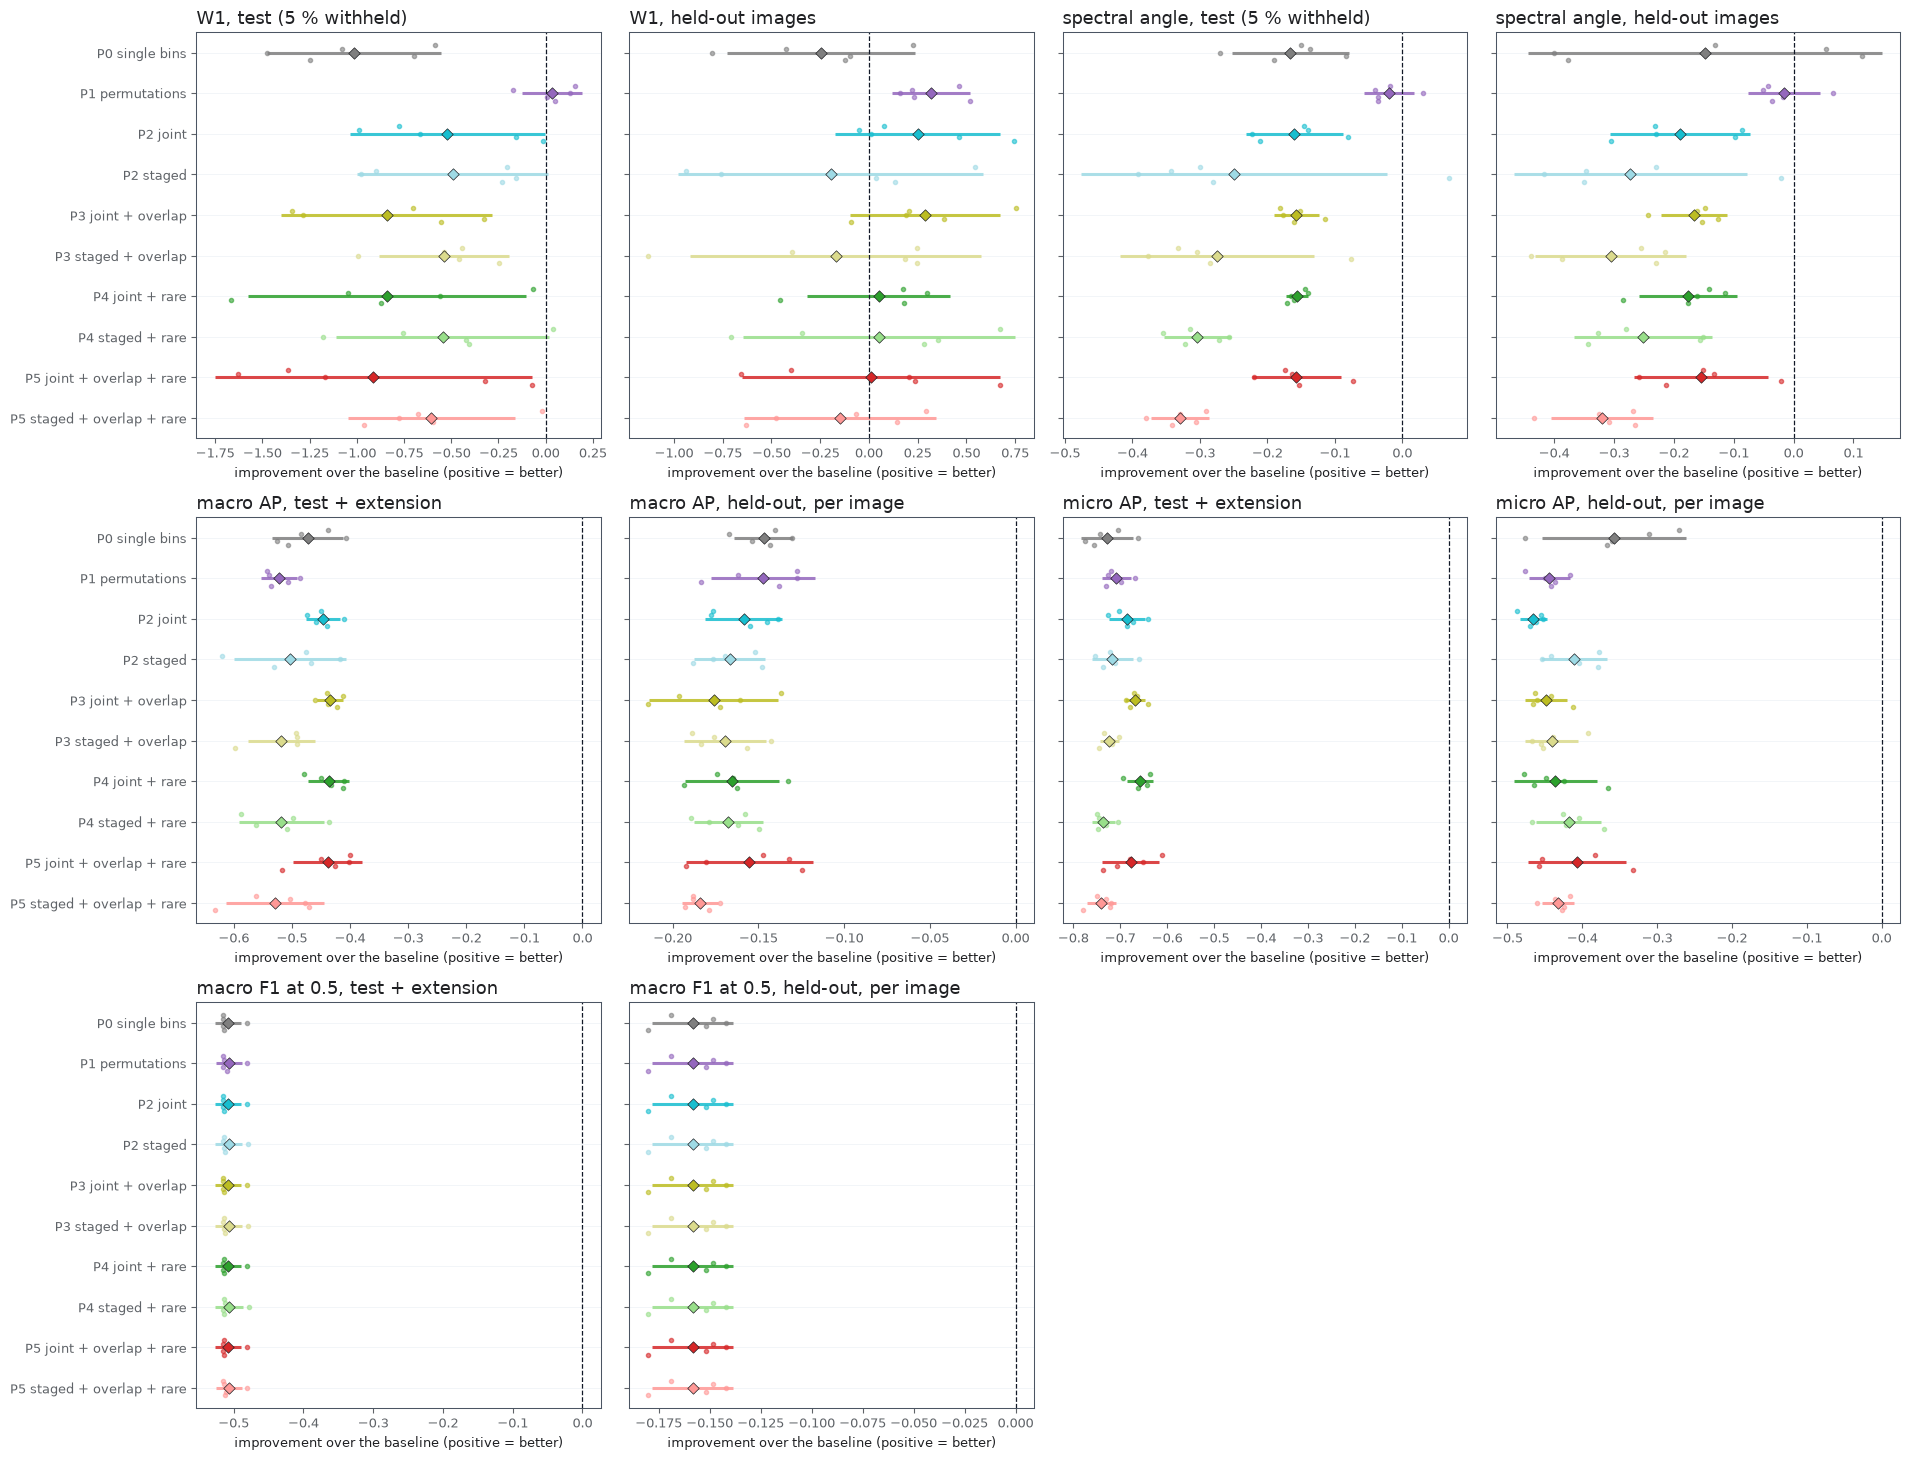

In [7]:
figures.improvement_forest(improvement_summary, panels=key_panels(), variants=VARIANTS, labels=VARIANT_LABELS,
                           colors=VARIANT_COLORS, paired=paired, columns=4, theme=theme);
rows = pd.concat([improvement_summary[(improvement_summary.family == spec['family']) & (improvement_summary.metric == spec['metric'])
                                      & (improvement_summary.ranking == spec.get('ranking', 'none'))] for spec in KEY_METRICS])
rows = rows[rows.evaluation.isin(EVALUATIONS)]
display(rows.assign(result=interval(rows), column=rows.metric.map(SHORT) + ' | ' + rows.evaluation)
        .pivot_table(index='variant', columns='column', values='result', aggfunc='first').reindex(VARIANTS))

### Remarks

- Of 130 variant x key-metric cells, 1 improve (interval above zero), 114 worsen and 15 are inconclusive.
- W1, test: mean improvement -1.02 to 0.0338 (best P1 permutations); interval above zero: none; below zero: P0 single bins, P2 joint, P3 joint + overlap, P3 staged + overlap, P4 joint + rare, P5 joint + overlap + rare, P5 staged + overlap + rare.
- W1, held-out: mean improvement -0.245 to 0.317 (best P1 permutations); interval above zero: P1 permutations; below zero: none.
- spectral angle, test: mean improvement -0.329 to -0.0199 (best P1 permutations); interval above zero: none; below zero: P0 single bins, P2 joint, P2 staged, P3 joint + overlap, P3 staged + overlap, P4 joint + rare, P4 staged + rare, P5 joint + overlap + rare, P5 staged + overlap + rare.
- spectral angle, held-out: mean improvement -0.32 to -0.0161 (best P1 permutations); interval above zero: none; below zero: P2 joint, P2 staged, P3 joint + overlap, P3 staged + overlap, P4 joint + rare, P4 staged + rare, P5 joint + overlap + rare, P5 staged + overlap + rare.
- macro AP, held-out: mean improvement -0.142 to -0.115 (best P1 permutations); interval above zero: none; below zero: P0 single bins, P1 permutations, P2 joint, P2 staged, P3 joint + overlap, P3 staged + overlap, P4 joint + rare, P4 staged + rare, P5 joint + overlap + rare, P5 staged + overlap + rare.
- macro AP, test+ext: mean improvement -0.529 to -0.435 (best P3 joint + overlap); interval above zero: none; below zero: P0 single bins, P1 permutations, P2 joint, P2 staged, P3 joint + overlap, P3 staged + overlap, P4 joint + rare, P4 staged + rare, P5 joint + overlap + rare, P5 staged + overlap + rare.
- macro AP, held-out per image: mean improvement -0.184 to -0.147 (best P0 single bins); interval above zero: none; below zero: P0 single bins, P1 permutations, P2 joint, P2 staged, P3 joint + overlap, P3 staged + overlap, P4 joint + rare, P4 staged + rare, P5 joint + overlap + rare, P5 staged + overlap + rare.
- micro AP, held-out: mean improvement -0.399 to -0.349 (best P0 single bins); interval above zero: none; below zero: P0 single bins, P1 permutations, P2 joint, P2 staged, P3 joint + overlap, P3 staged + overlap, P4 joint + rare, P4 staged + rare, P5 joint + overlap + rare, P5 staged + overlap + rare.
- micro AP, test+ext: mean improvement -0.74 to -0.658 (best P4 joint + rare); interval above zero: none; below zero: P0 single bins, P1 permutations, P2 joint, P2 staged, P3 joint + overlap, P3 staged + overlap, P4 joint + rare, P4 staged + rare, P5 joint + overlap + rare, P5 staged + overlap + rare.
- micro AP, held-out per image: mean improvement -0.465 to -0.357 (best P0 single bins); interval above zero: none; below zero: P0 single bins, P1 permutations, P2 joint, P2 staged, P3 joint + overlap, P3 staged + overlap, P4 joint + rare, P4 staged + rare, P5 joint + overlap + rare, P5 staged + overlap + rare.
- macro F1@0.5, held-out: mean improvement -0.128 to -0.128 (best P0 single bins); interval above zero: none; below zero: P0 single bins, P1 permutations, P2 joint, P2 staged, P3 joint + overlap, P3 staged + overlap, P4 joint + rare, P4 staged + rare, P5 joint + overlap + rare, P5 staged + overlap + rare.
- macro F1@0.5, test+ext: mean improvement -0.508 to -0.507 (best P4 staged + rare); interval above zero: none; below zero: P0 single bins, P1 permutations, P2 joint, P2 staged, P3 joint + overlap, P3 staged + overlap, P4 joint + rare, P4 staged + rare, P5 joint + overlap + rare, P5 staged + overlap + rare.
- macro F1@0.5, held-out per image: mean improvement -0.158 to -0.158 (best P0 single bins); interval above zero: none; below zero: P0 single bins, P1 permutations, P2 joint, P2 staged, P3 joint + overlap, P3 staged + overlap, P4 joint + rare, P4 staged + rare, P5 joint + overlap + rare, P5 staged + overlap + rare.

### Notes

## Relative improvement over the complete metric set

### Methodology

#### Theoretical

The key metrics may hide a trade-off. The relative improvement $\Delta_r / |b_r|$ puts every
reconstruction and head metric on one scale (fraction of the baseline value).

#### Implementation

Mean over repetitions of `relative_improvement` from `improvements`; reconstruction on test and held-out,
head (annotation retrieval) on test, test + extension and held-out.

#### Figure descriptions

Heat map: rows = variants, columns = metric | evaluation, colour = mean relative improvement clipped to
[-1, 1], diverging around 0 = baseline: red = better than the baseline, blue = worse; the colour range is
symmetric around the largest absolute value shown. Values beyond the clip are listed below the figure.

relative_improvement
variant           column                                            
P0_single         hamming_loss | test                          -2.30
                  hamming_loss | test_combined                 -1.89
P1_permutation    hamming_loss | test                          -2.31
                  hamming_loss | test_combined                 -1.90
P2_joint_base     hamming_loss | test                          -2.31
                  hamming_loss | test_combined                 -1.89
P2_staged_base    hamming_loss | test                          -2.33
                  hamming_loss | test_combined                 -1.91
                  mse | heldout_image                          -1.23
P3_joint_overlap  hamming_loss | test                          -2.30
                  hamming_loss | test_combined                 -1.89
P3_staged_overlap hamming_loss | test                          -2.32
                  hamming_loss | test_combined                 -1.90
                  mse | heldout_image                          -1.43
P4_joint_rare     hamming_loss | test                          -2.30
                  hamming_loss | test_combined                 -1.89
P4_staged_rare    hamming_loss | test                          -2.33
                  hamming_loss | test_combined                 -1.91
                  mse | heldout_image                          -1.16
                  mse | test                                   -1.09
P5_joint_all      hamming_loss | test                          -2.30
                  hamming_loss | test_combined                 -1.89
P5_staged_all     hamming_loss | test                          -2.31
                  hamming_loss | test_combined                 -1.90
                  mse | heldout_image                          -1.47
                  mse | test                                   -1.29

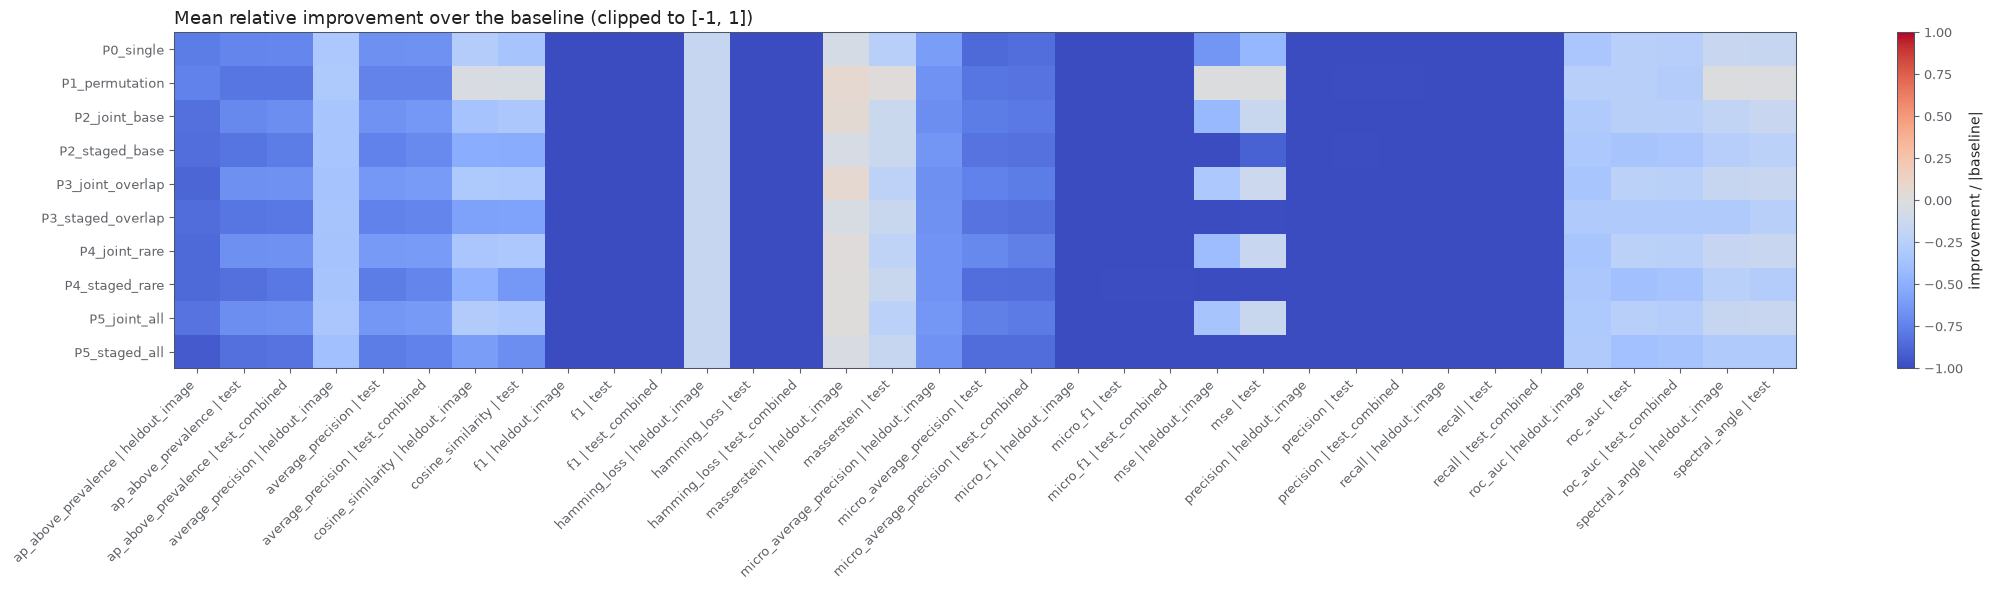

In [8]:
full = paired[paired.evaluation.isin(['test', 'test_combined', 'heldout_image']) & paired.ranking.isin(['none', 'annotation_retrieval'])]
matrix = (full.assign(column=full.metric + ' | ' + full.evaluation)
          .pivot_table(index='variant', columns='column', values='relative_improvement', aggfunc='mean').reindex(VARIANTS))
figures.matrix_heatmap(matrix.clip(-1, 1), title='Mean relative improvement over the baseline (clipped to [-1, 1])',
                       colorbar_label='improvement / |baseline|', diverging=True, theme=theme);
beyond = matrix.stack()
beyond = beyond[beyond.abs() > 1]
if beyond.empty:
    print('No mean relative improvement beyond [-1, 1].')
else:
    display(beyond.rename('relative_improvement').round(2).to_frame())

### Remarks

- Largest mean relative improvements: P1 permutations masserstein held-out 0.0694; P3 joint + overlap masserstein held-out 0.064; P2 joint masserstein held-out 0.0538.
- Largest mean relative losses: P2 staged hamming_loss test -2.33; P4 staged + rare hamming_loss test -2.33; P3 staged + overlap hamming_loss test -2.32.

### Notes

## Generalization gap to new images

### Methodology

#### Theoretical

The gap $g = v^{\mathrm{heldout}} - v^{\mathrm{test}}$ measures how much a model loses from new pixels
of seen images to new images. Its improvement $s_m (g^{v}_r - g^{b}_r)$ is positive when the variant
loses less than the baseline (for lower-is-better metrics: when its held-out error grows less).

#### Implementation

`generalization_gap` holds the gap per model and its paired improvement; summarized here with the
library's `summarize` (same t interval).

#### Figure descriptions

Forest plot as above, one panel per key metric; the table gives the interval strings.

metric,average_precision,f1,masserstein,micro_average_precision,spectral_angle
variant,,,,,
P0_single,"0.354 [0.313, 0.394] (+5/-0)","0.377 [0.356, 0.398] (+5/-0)","0.771 [0.508, 1.03] (+5/-0)","0.407 [0.335, 0.478] (+5/-0)","0.0177 [-0.203, 0.238] (+3/-2)"
P1_permutation,"0.402 [0.379, 0.425] (+5/-0)","0.376 [0.354, 0.399] (+5/-0)","0.283 [0.0721, 0.495] (+5/-0)","0.318 [0.286, 0.35] (+5/-0)","0.00376 [-0.0255, 0.033] (+2/-3)"
P2_joint_base,"0.335 [0.302, 0.367] (+5/-0)","0.377 [0.355, 0.398] (+5/-0)","0.77 [0.61, 0.93] (+5/-0)","0.279 [0.223, 0.335] (+5/-0)","-0.0297 [-0.105, 0.0455] (+1/-4)"
P2_staged_base,"0.391 [0.292, 0.49] (+5/-0)","0.376 [0.354, 0.398] (+5/-0)","0.296 [-0.0667, 0.659] (+4/-1)","0.345 [0.305, 0.384] (+5/-0)","-0.0235 [-0.101, 0.0541] (+1/-4)"
P3_joint_overlap,"0.302 [0.248, 0.355] (+5/-0)","0.377 [0.356, 0.398] (+5/-0)","1.13 [0.505, 1.75] (+5/-0)","0.26 [0.203, 0.317] (+5/-0)","-0.00901 [-0.054, 0.036] (+2/-3)"
P3_staged_overlap,"0.388 [0.356, 0.42] (+5/-0)","0.376 [0.355, 0.398] (+5/-0)","0.366 [-0.0744, 0.806] (+4/-1)","0.332 [0.29, 0.373] (+5/-0)","-0.0302 [-0.239, 0.179] (+3/-2)"
P4_joint_rare,"0.301 [0.252, 0.349] (+5/-0)","0.377 [0.355, 0.398] (+5/-0)","0.891 [0.324, 1.46] (+5/-0)","0.249 [0.168, 0.329] (+5/-0)","-0.0199 [-0.0943, 0.0546] (+3/-2)"
P4_staged_rare,"0.405 [0.338, 0.472] (+5/-0)","0.376 [0.354, 0.397] (+5/-0)","0.598 [0.41, 0.785] (+5/-0)","0.359 [0.312, 0.407] (+5/-0)","0.0521 [-0.019, 0.123] (+4/-1)"
P5_joint_all,"0.316 [0.255, 0.377] (+5/-0)","0.377 [0.355, 0.398] (+5/-0)","0.925 [0.546, 1.3] (+5/-0)","0.295 [0.228, 0.362] (+5/-0)","0.00168 [-0.0588, 0.0622] (+3/-2)"


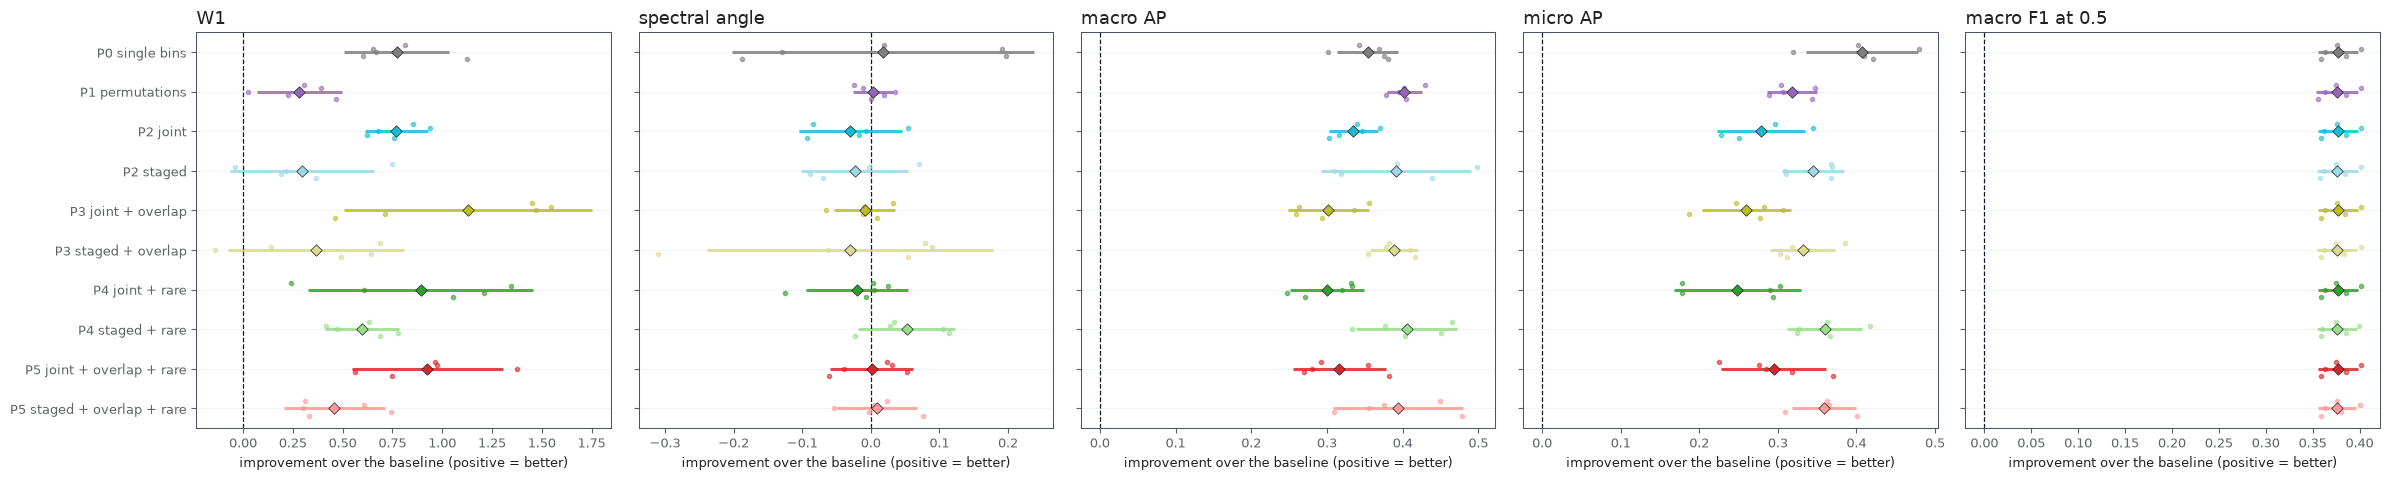

In [9]:
gap = table('generalization_gap')
gap_summary = summarize(gap, ['variant', 'family', 'metric', 'ranking'])
panels = [(SHORT[spec['metric']], {'family': spec['family'], 'metric': spec['metric'], 'ranking': spec.get('ranking', 'none')})
          for spec in KEY_METRICS]
figures.improvement_forest(gap_summary, panels=panels, variants=VARIANTS, labels=VARIANT_LABELS, colors=VARIANT_COLORS,
                           paired=gap, columns=5, theme=theme);
shown = gap_summary[gap_summary.metric.isin(SHORT) & gap_summary.ranking.isin(['none', 'annotation_retrieval'])]
display(shown.assign(result=interval(shown)).pivot_table(index='variant', columns='metric', values='result', aggfunc='first').reindex(VARIANTS))

### Remarks

- macro AP: smaller loss to new images than the baseline for P0 single bins, P1 permutations, P2 joint, P2 staged, P3 joint + overlap, P3 staged + overlap, P4 joint + rare, P4 staged + rare, P5 joint + overlap + rare, P5 staged + overlap + rare; larger loss for no variant.
- macro F1@0.5: smaller loss to new images than the baseline for P0 single bins, P1 permutations, P2 joint, P2 staged, P3 joint + overlap, P3 staged + overlap, P4 joint + rare, P4 staged + rare, P5 joint + overlap + rare, P5 staged + overlap + rare; larger loss for no variant.
- micro AP: smaller loss to new images than the baseline for P0 single bins, P1 permutations, P2 joint, P2 staged, P3 joint + overlap, P3 staged + overlap, P4 joint + rare, P4 staged + rare, P5 joint + overlap + rare, P5 staged + overlap + rare; larger loss for no variant.
- W1: smaller loss to new images than the baseline for P0 single bins, P1 permutations, P2 joint, P3 joint + overlap, P4 joint + rare, P4 staged + rare, P5 joint + overlap + rare, P5 staged + overlap + rare; larger loss for no variant.
- spectral angle: smaller loss to new images than the baseline for no variant; larger loss for no variant.
- Caveat: at this stage the variants are far below the baseline (on the head metrics), so a smaller loss to new images is a level artefact, not better generalization: a model near chance on both populations has nothing to lose (e.g. its held-out macro AP is close to the prevalence of the few held-out classes, see the prediction notebook).

### Notes

## Variant ranking used to pick the displayed variant

### Methodology

#### Theoretical

Images and representatives in later notebooks show the best variant of each stage. It is the variant with
the lowest mean rank of its mean improvement over the five key metrics on the withheld **test** pixels
(never on the held-out images that are displayed); equal mean ranks are decided by the macro-AP improvement.

#### Implementation

`variant_ranking` (mean rank, tie-break rank, final rank).

#### Figure descriptions

No figure.

In [10]:
display(table('variant_ranking').drop(columns=['axis']))

,variant,mean_rank,tie_rank,rank,stage
0,P1_permutation,3.2,6.0,1,frozen_head
1,P4_joint_rare,3.8,1.0,2,frozen_head
2,P3_joint_overlap,4.8,2.0,3,frozen_head
3,P5_joint_all,4.8,3.0,4,frozen_head
4,P2_joint_base,4.8,4.0,5,frozen_head
5,P2_staged_base,5.6,8.0,6,frozen_head
6,P3_staged_overlap,6.0,7.0,7,frozen_head
7,P4_staged_rare,6.6,10.0,8,frozen_head
8,P5_staged_all,7.2,9.0,9,frozen_head
9,P0_single,8.2,5.0,10,frozen_head


### Remarks

- Best variant on the test pixels: P1 permutations (mean rank 3.2 of 10); last: P0 single bins (8.2). Mean ranks span 3.2-8.2. The spread is small, so the choice of the displayed variant is weakly determined.

### Notes

## Results / Summary

### LLM

- **Observed:** 1 of 130 variant x key-metric cells improve on the baseline, 114 worsen, 15 are inconclusive (95 % t interval, five paired repetitions).
- **Observed:** test W1 3.95-5 against 3.99 for the baseline; macro AP (test + extension) 0.179-0.274 against 0.708.
- **Interpretation:** 10 real epochs repair the reconstruction (W1 close to the baseline; held-out W1 better than the baseline for P1 permutations) but not the head: the frozen synthetic head keeps the head metrics far below the baseline (macro AP a quarter to a third of the baseline's, F1 = 0 because no probability reaches 0.5). The linear probe (part 3_04) shows that the representation itself carries as much annotation information as the baseline's, so the frozen head, not the encoder, is the bottleneck.

**Absolute levels against the real-only baseline** (means over repetitions; 'better' compares means only, without a test; the intervals are in the improvement sections):

- W1, test: baseline 3.988; others 3.954-5.004; 1 of 10 better than the baseline; best P1 permutations (3.954), worst P0 single bins (5.004).
- W1, heldout_image: baseline 4.467; others 4.15-4.713; 6 of 10 better than the baseline; best P1 permutations (4.15), worst P0 single bins (4.713).
- spectral angle, test: baseline 1.094; others 1.114-1.424; 0 of 10 better than the baseline; best P1 permutations (1.114), worst P5 staged + overlap + rare (1.424).
- spectral angle, heldout_image: baseline 1.058; others 1.074-1.378; 0 of 10 better than the baseline; best P1 permutations (1.074), worst P5 staged + overlap + rare (1.378).
- macro AP, test_combined: baseline 0.7084; others 0.1793-0.2738; 0 of 10 better than the baseline; best P3 joint + overlap (0.2738), worst P5 staged + overlap + rare (0.1793).
- macro AP, heldout_image_per_image: baseline 0.6105; others 0.4263-0.4636; 0 of 10 better than the baseline; best P0 single bins (0.4636), worst P5 staged + overlap + rare (0.4263).
- micro AP, test_combined: baseline 0.8696; others 0.1294-0.2116; 0 of 10 better than the baseline; best P4 joint + rare (0.2116), worst P5 staged + overlap + rare (0.1294).
- micro AP, heldout_image_per_image: baseline 0.7966; others 0.3314-0.4396; 0 of 10 better than the baseline; best P0 single bins (0.4396), worst P2 joint (0.3314).
- macro F1 at 0.5, test_combined: baseline 0.508; others 0-0.001339; 0 of 10 better than the baseline; best P4 staged + rare (0.001339), worst P0 single bins (0).
- macro F1 at 0.5, heldout_image_per_image: baseline 0.1583; others 0-0; 0 of 10 better than the baseline; best P0 single bins (0), worst P0 single bins (0).

### Person